In [1]:
import pandas as pd

# ----------------------------
# 0.1 Cargar solo columnas necesarias
# ----------------------------

# Viviendas
cols_vivienda = [
    "id_vivienda",
    "region",
    "comuna",            # en el diccionario aparece como "comuna"
    "p4a_mat_paredes",   # materialidad paredes
    "p4b_mat_techo",     # materialidad techo
    "p4c_mat_piso",       # materialidad piso
    "indice_hacinamiento"   # índice de hacinamiento, en la tarea aparece en hogar, pero en el diccionario aparece en vivienda
]

vivienda = pd.read_parquet(
    "viviendas_censo2024.parquet",
    columns=cols_vivienda
)

# Hogares
cols_hogar = [
    "id_vivienda",
    "id_hogar",
    "p12_tenencia_viv"      # tenencia
]

hogar = pd.read_parquet(
    "hogares_censo2024.parquet",
    columns=cols_hogar
)

# Personas
cols_persona = [
    "id_vivienda",
    "id_hogar",
    "id_persona",
    "sexo",
    "edad",
    "p27_nacionalidad",
    "p27_nacionalidad_rec",
    "p24_lug_resid5",
    "p25_lug_nacimiento",
    "p26_llegada_periodo",
    "escolaridad",
    "cine11",
    "sit_fuerza_trabajo",
    "cod_ciuo",
    "cod_caenes",
    "p45_medio_transporte"
]

persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=cols_persona
)

# ----------------------------
# 0.2 Joins
# ----------------------------

# Primero: persona + hogar
persona_hogar = persona.merge(
    hogar,
    on=["id_vivienda", "id_hogar"],
    how="left"
)

# Luego: + vivienda
censo = persona_hogar.merge(
    vivienda,
    on="id_vivienda",
    how="left"
)

# ----------------------------
# Revisar resultado
# ----------------------------
print("Vivienda:", vivienda.shape)
print("Hogar:", hogar.shape)
print("Persona:", persona.shape)
print("Base final:", censo.shape)

censo.head()

Vivienda: (7664466, 7)
Hogar: (6622597, 3)
Persona: (18480432, 16)
Base final: (18480432, 23)


,id_vivienda,id_hogar,id_persona,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,...,cod_ciuo,cod_caenes,p45_medio_transporte,p12_tenencia_viv,region,comuna,p4a_mat_paredes,p4b_mat_techo,p4c_mat_piso,indice_hacinamiento
0,1,1,1,2,80,1,1,3,2,NaN,...,NaN,NaN,NaN,4.0,5,5802,5.0,1.0,2.0,1.0
1,1,1,2,1,52,1,1,2,2,NaN,...,7.0,F,2.0,4.0,5,5802,5.0,1.0,2.0,1.0
2,1,1,3,2,45,1,1,2,2,NaN,...,2.0,P,3.0,4.0,5,5802,5.0,1.0,2.0,1.0
3,1,1,4,2,8,1,1,2,1,NaN,...,NaN,NaN,NaN,4.0,5,5802,5.0,1.0,2.0,1.0
4,2,1,1,1,69,1,1,3,2,NaN,...,NaN,NaN,NaN,9.0,4,4303,2.0,3.0,3.0,1.0


In [2]:
# Filtrar por comunas de interés
#Codigo comunas Ñuñoa: 13120 ; San Joaquín:13129 ; San José de Maipo:13203 
MY_COMUNAS = [13120, 13129, 13203]  

# Filtrar vivienda
viv = vivienda[vivienda["comuna"].isin(MY_COMUNAS)].copy()

# Usar viviendas filtradas para arrastrar hogares y personas
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

# Reportar número de filas
print(f"Filas en vivienda filtrada: {len(viv):,}")
print(f"Filas en hogar filtrada: {len(hog):,}")
print(f"Filas en persona filtrada: {len(per):,}")

Filas en vivienda filtrada: 163,572
Filas en hogar filtrada: 148,675
Filas en persona filtrada: 354,510


In [3]:
#3 Joint
df = (
    per.merge(hog, on=["id_vivienda", "id_hogar"], how="left")
       .merge(viv, on="id_vivienda", how="left")
)

# Verificación
assert len(df) == len(per), "Row count mismatch after join!"

# =========================
# 4. Reportar shape e info
# =========================

print("df.shape =", df.shape)
print()
df.info()

df.shape = (354510, 23)

<class 'pandas.DataFrame'>
RangeIndex: 354510 entries, 0 to 354509
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_vivienda           354510 non-null  int32  
 1   id_hogar              354510 non-null  int32  
 2   id_persona            354510 non-null  int32  
 3   sexo                  354510 non-null  int32  
 4   edad                  354510 non-null  int32  
 5   p27_nacionalidad      354510 non-null  int32  
 6   p27_nacionalidad_rec  354510 non-null  int32  
 7   p24_lug_resid5        354510 non-null  int32  
 8   p25_lug_nacimiento    354510 non-null  int32  
 9   p26_llegada_periodo   48544 non-null   float64
 10  escolaridad           354510 non-null  int32  
 11  cine11                354510 non-null  int32  
 12  sit_fuerza_trabajo    305588 non-null  float64
 13  cod_ciuo              195707 non-null  float64
 14  cod_caenes            195707 non-null 

In [4]:
#Como hay que filtrar edad y nacionalidad ==-99 y ver que sexo y p27_nacionalidad_rec vengan codificados de la misma forma, se verifica los valores únicos de cada una de estas variables para ver si hay que hacer alguna transformación antes de filtrar
print(sorted(df["sexo"].dropna().unique()))
print(sorted(df["p27_nacionalidad_rec"].dropna().unique()))

[np.int32(1), np.int32(2)]
[np.int32(-99), np.int32(1), np.int32(2)]


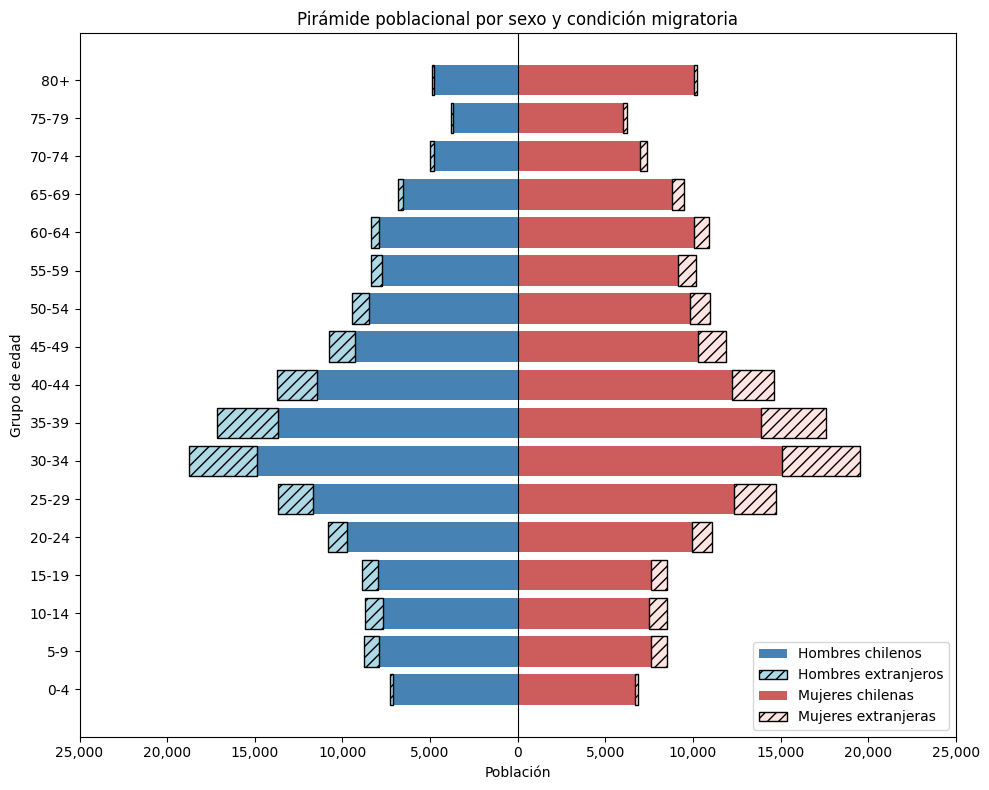

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# 1. Filtrar edades y nacionalidad válidas
# -----------------------------------
pyr = df[(df["edad"] != -99) & (df["p27_nacionalidad_rec"] != -99)].copy()

# -----------------------------------
# 2. Crear grupos de edad
# -----------------------------------
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]

pyr["age_group"] = pd.cut(
    pyr["edad"],
    bins=bins,
    labels=labels,
    right=False
)

# -----------------------------------
# 3. Recodificar sexo y nacionalidad
# -----------------------------------
# Asumiendo:
# sexo: 1 = hombre, 2 = mujer
# p27_nacionalidad_rec: 1 = chileno/a, 2 = extranjero/a

pyr["sexo_cat"] = pyr["sexo"].map({
    1: "Hombre",
    2: "Mujer"
})

pyr["nac_cat"] = pyr["p27_nacionalidad_rec"].map({
    1: "Chileno/a",
    2: "Extranjero/a"
})

# Eliminar cualquier caso no reconocido
pyr = pyr[pyr["sexo_cat"].notna() & pyr["nac_cat"].notna() & pyr["age_group"].notna()].copy()

# -----------------------------------
# 4. Tabla de conteos
# -----------------------------------
tab = (
    pyr.groupby(["age_group", "sexo_cat", "nac_cat"], observed=False)
       .size()
       .reset_index(name="n")
)

male_chile = (
    tab[(tab["sexo_cat"] == "Hombre") & (tab["nac_cat"] == "Chileno/a")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

male_foreign = (
    tab[(tab["sexo_cat"] == "Hombre") & (tab["nac_cat"] == "Extranjero/a")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

female_chile = (
    tab[(tab["sexo_cat"] == "Mujer") & (tab["nac_cat"] == "Chileno/a")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

female_foreign = (
    tab[(tab["sexo_cat"] == "Mujer") & (tab["nac_cat"] == "Extranjero/a")]
    .set_index("age_group")["n"]
    .reindex(labels, fill_value=0)
)

# Hombres a la izquierda
male_chile_neg = -male_chile
male_foreign_neg = -male_foreign

# -----------------------------------
# 5. Graficar
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(labels))

# Hombres
ax.barh(
    y,
    male_chile_neg,
    color="steelblue",
    label="Hombres chilenos"
)

ax.barh(
    y,
    male_foreign_neg,
    left=male_chile_neg,
    color="lightblue",
    hatch="///",
    edgecolor="black",
    label="Hombres extranjeros"
)

# Mujeres
ax.barh(
    y,
    female_chile,
    color="indianred",
    label="Mujeres chilenas"
)

ax.barh(
    y,
    female_foreign,
    left=female_chile,
    color="mistyrose",
    hatch="///",
    edgecolor="black",
    label="Mujeres extranjeras"
)

# Formato
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.axvline(0, color="black", linewidth=0.8)

# Etiquetas del eje x en valor absoluto
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{abs(int(x)):,}" for x in xticks])

ax.set_xlabel("Población")
ax.set_ylabel("Grupo de edad")
ax.set_title("Pirámide poblacional por sexo y condición migratoria")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [6]:
# 1.2 Dependency ratio

dep = df[df["edad"] != -99].copy()

dep["grupo_dep"] = pd.cut(
    dep["edad"],
    bins=[0, 15, 65, 200],
    labels=["0-14", "15-64", "65+"],
    right=False
)

tabla_dep = (
    dep.groupby(["comuna", "grupo_dep"], observed=False)
       .size()
       .unstack(fill_value=0)
)

tabla_dep["dependency_ratio"] = (
    (tabla_dep["0-14"] + tabla_dep["65+"]) / tabla_dep["15-64"]
)

mapa_comunas = {
    13120: "Ñuñoa",
    13129: "San Joaquín",
    13203: "San José de Maipo"
}

resultado_dep = tabla_dep.reset_index()[["comuna", "0-14", "15-64", "65+", "dependency_ratio"]]
resultado_dep["nombre_comuna"] = resultado_dep["comuna"].map(mapa_comunas)
resultado_dep["dependency_ratio"] = resultado_dep["dependency_ratio"].round(3)
resultado_dep = resultado_dep[["comuna", "nombre_comuna", "0-14", "15-64", "65+", "dependency_ratio"]]

print(resultado_dep)

grupo_dep  comuna      nombre_comuna   0-14   15-64    65+  dependency_ratio
0           13120              Ñuñoa  31138  174549  35780             0.383
1           13129        San Joaquín  14852   64957  15793             0.472
2           13203  San José de Maipo   2932   11748   2761             0.485


El proporción de dependencia varía entre las comunas analizadas, siendo más bajo en Ñuñoa (0.383) y más alto en San Joaquín (0.472) y San José de Maipo (0.485).

El resultado de Ñuñoa es consistente con lo esperado, ya que es una comuna con alta presencia de población joven y en edad de trabajar, lo que reduce la proporción de dependientes.

En cambio, las otras comunas presentan ratios más elevados, lo que sugiere una mayor proporción de población dependiente (ya sea infantil o adulta mayor). Aunque no tenía una expectativa previa sobre estas comunas, los resultados indican una estructura demográfica menos concentrada en población activa en comparación con Ñuñoa.

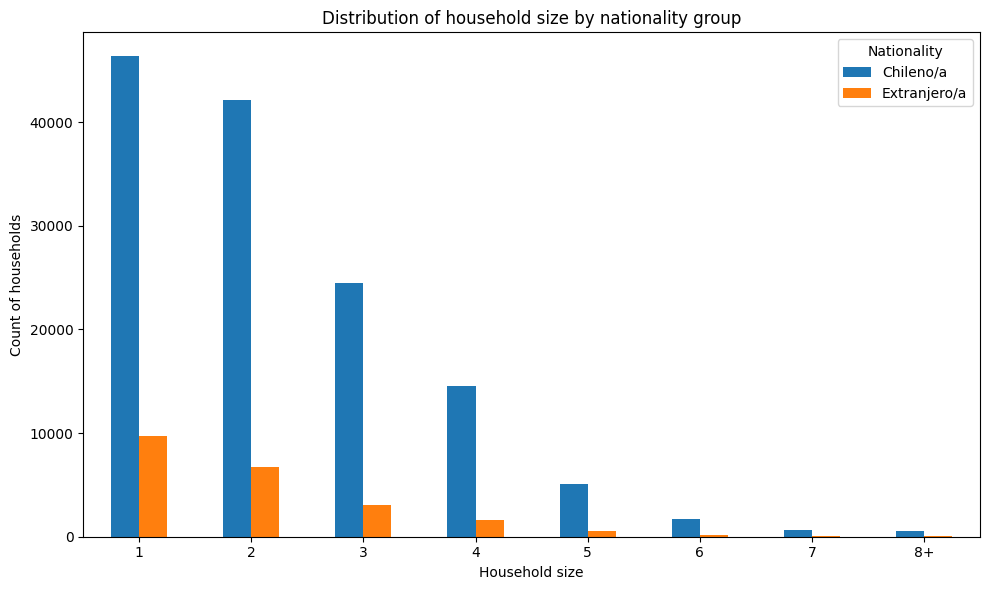

In [7]:
# Household size distribution by nationality group

# Filtrar nacionalidad válida
hh = df[df["p27_nacionalidad_rec"] != -99].copy()

# Recodificar nacionalidad
hh["nac_cat"] = hh["p27_nacionalidad_rec"].map({
    1: "Chileno/a",
    2: "Extranjero/a"
})

# Número de personas por hogar y grupo de nacionalidad
hh_size = (
    hh.groupby(["id_vivienda", "id_hogar", "nac_cat"])
      .size()
      .reset_index(name="tam_hogar")
)

# Agrupar tamaños: 1, 2, 3, ..., 7, 8+
hh_size["tam_cat"] = hh_size["tam_hogar"].clip(upper=8).astype(str)
hh_size.loc[hh_size["tam_cat"] == "8", "tam_cat"] = "8+"

# Distribución
dist_hh = (
    hh_size.groupby(["tam_cat", "nac_cat"], observed=False)
           .size()
           .unstack(fill_value=0)
)

orden = ["1", "2", "3", "4", "5", "6", "7", "8+"]
dist_hh = dist_hh.reindex(orden, fill_value=0)

# Bar chart
dist_hh.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Household size")
plt.ylabel("Count of households")
plt.title("Distribution of household size by nationality group")
plt.xticks(rotation=0)
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

La distribución muestra que la mayoría de los hogares, tanto chilenos como extranjeros, se concentran en tamaños pequeños (1 a 3 personas), siendo especialmente frecuentes los hogares de 1 y 2 integrantes.

Al comparar por nacionalidad, se observa que los hogares extranjeros tienen relativamente mayor presencia en tamaños más grandes (4 o más personas) en comparación con los hogares chilenos, los cuales se concentran más en tamaños pequeños.

En particular, la proporción de hogares de 1 persona es más alta entre los chilenos, mientras que los extranjeros tienden a vivir en hogares más numerosos, lo que podría reflejar estrategias de convivencia para compartir costos o redes familiares más extensas.

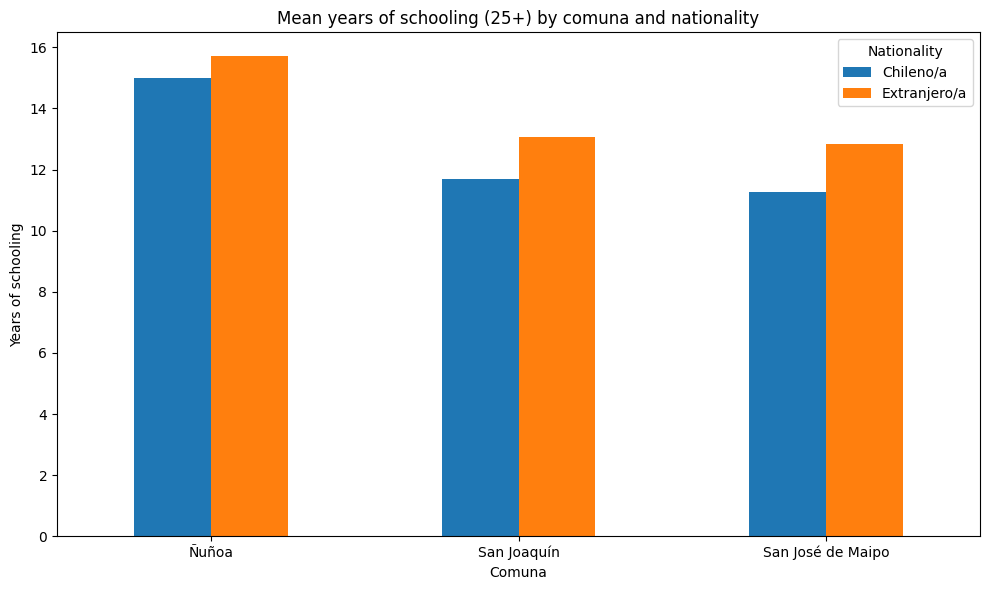

In [8]:
# Education (25+) and Employment Rate (15–64) by comuna and nationality

# -----------------------------------
# 1. Filtrar y recodificar nacionalidad
# -----------------------------------
sub = df[(df["p27_nacionalidad_rec"] != -99) & (df["edad"] != -99)].copy()

sub["nac_cat"] = sub["p27_nacionalidad_rec"].map({
    1: "Chileno/a",
    2: "Extranjero/a"
})

# -----------------------------------
# 2. Mean years of schooling (25+)
# -----------------------------------
edu = sub[sub["edad"] >= 25].copy()

edu_mean = (
    edu.groupby(["comuna", "nac_cat"], observed=False)["escolaridad"]
       .mean()
       .unstack()
)

# -----------------------------------
# 3. Employment rate (15–64)
# -----------------------------------
emp = sub[(sub["edad"] >= 15) & (sub["edad"] < 65)].copy()

# ⚠️ AJUSTAR si el código de "ocupado" es distinto
# Usualmente: 1 = ocupado
emp["ocupado"] = (emp["sit_fuerza_trabajo"] == 1).astype(int)

emp_rate = (
    emp.groupby(["comuna", "nac_cat"], observed=False)["ocupado"]
       .mean()
       .unstack()
)

# -----------------------------------
# 4. Graficar (dos gráficos separados)
# -----------------------------------
import matplotlib.pyplot as plt

# Diccionario de comunas
mapa_comunas = {
    13120: "Ñuñoa",
    13129: "San Joaquín",
    13203: "San José de Maipo"
}
# Educación
ax = edu_mean.plot(kind="bar", figsize=(10,6))
ax.set_title("Mean years of schooling (25+) by comuna and nationality")
ax.set_ylabel("Years of schooling")
ax.set_xlabel("Comuna")
ax.set_xticklabels([mapa_comunas[c] for c in edu_mean.index], rotation=0)
ax.legend(title="Nationality")
plt.tight_layout()
plt.show()

   comuna      nombre_comuna  pct_foreign
0   13120              Ñuñoa        12.19
1   13129        San Joaquín        14.15
2   13203  San José de Maipo         3.75


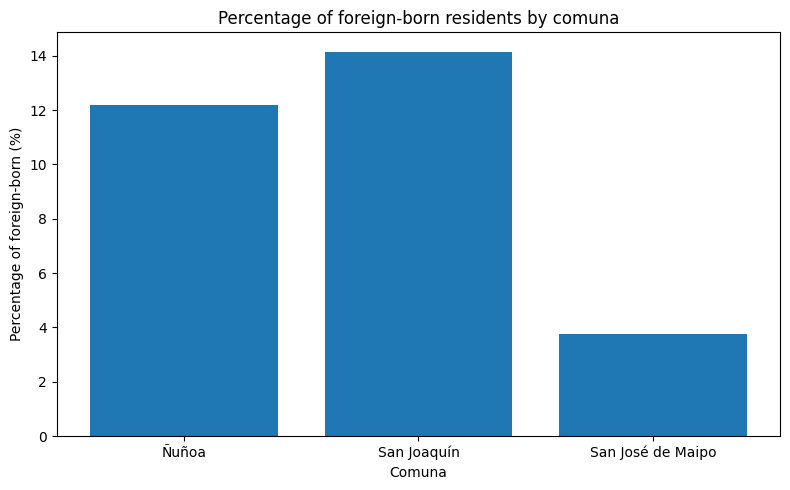

In [9]:
# 2.1 Percentage foreign-born by comuna

# Filtrar datos válidos
fb = df[(df["p27_nacionalidad_rec"] != -99)].copy()

# Crear indicador de extranjero
fb["extranjero"] = (fb["p27_nacionalidad_rec"] == 2).astype(int)

# Calcular porcentaje por comuna
pct_foreign = (
    fb.groupby("comuna")["extranjero"]
      .mean()
      .reset_index(name="pct_foreign")
)

# Pasar a porcentaje
pct_foreign["pct_foreign"] = (pct_foreign["pct_foreign"] * 100).round(2)

# Mapear nombres de comunas
mapa_comunas = {
    13120: "Ñuñoa",
    13129: "San Joaquín",
    13203: "San José de Maipo"
}

pct_foreign["nombre_comuna"] = pct_foreign["comuna"].map(mapa_comunas)

# Ordenar columnas
pct_foreign = pct_foreign[["comuna", "nombre_comuna", "pct_foreign"]]

print(pct_foreign)


# -----------------------------------
# Bar chart
# -----------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(pct_foreign["nombre_comuna"], pct_foreign["pct_foreign"])

plt.ylabel("Percentage of foreign-born (%)")
plt.xlabel("Comuna")
plt.title("Percentage of foreign-born residents by comuna")

plt.tight_layout()
plt.show()

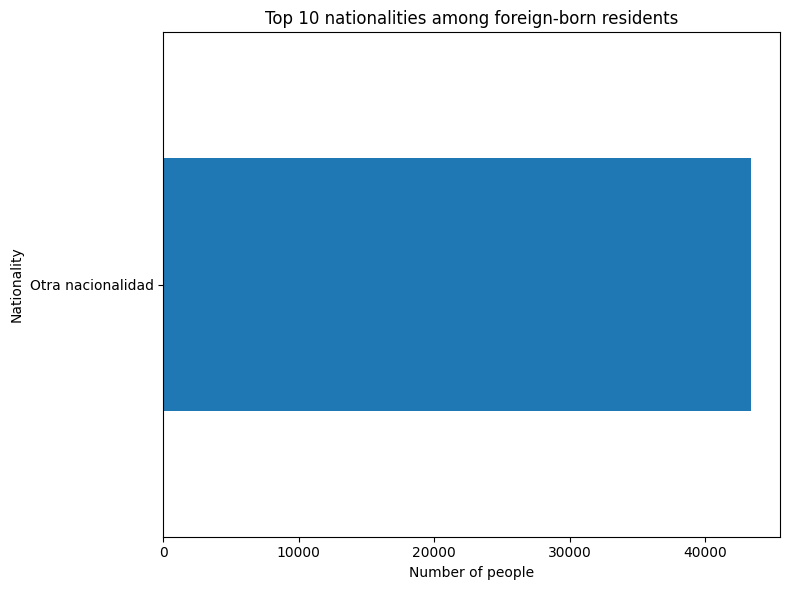

In [10]:
# 2.2 Top 10 nationalities among foreign-born residents

# Filtrar solo extranjeros y valores válidos
nat = df[
    (df["p27_nacionalidad_rec"] == 2) &
    (df["p27_nacionalidad"] != -99)
].copy()

# Contar nacionalidades
top_nat = (
    nat["p27_nacionalidad"]
    .value_counts()
    .head(10)
)

# -----------------------------------
# Diccionario (EJEMPLO — AJUSTAR según tu diccionario real)
# -----------------------------------
mapa_nacionalidades = {
    3: "Otra nacionalidad"
}

# Reemplazar códigos por nombres
top_nat.index = top_nat.index.map(mapa_nacionalidades)

# -----------------------------------
# Gráfico horizontal
# -----------------------------------
import matplotlib.pyplot as plt

top_nat.sort_values().plot(kind="barh", figsize=(8,6))

plt.xlabel("Number of people")
plt.ylabel("Nationality")
plt.title("Top 10 nationalities among foreign-born residents")

plt.tight_layout()
plt.show()

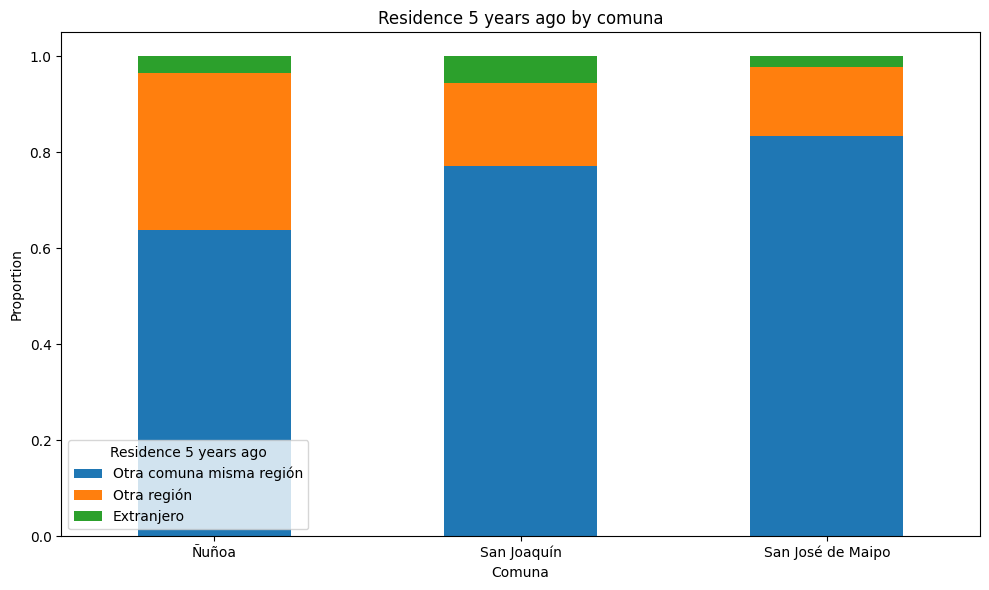

In [11]:
# 2.3 Migration status: residence 5 years ago

mig = df[
    (df["edad"] >= 5) &
    (df["p24_lug_resid5"] != -99)
].copy()

mapa_resid = {
    2: "Otra comuna misma región",
    3: "Otra región",
    4: "Extranjero"
}

mig["resid_cat"] = mig["p24_lug_resid5"].map(mapa_resid)
mig = mig[mig["resid_cat"].notna()].copy()

dist_mig = (
    mig.groupby(["comuna", "resid_cat"], observed=False)
       .size()
       .unstack(fill_value=0)
)

# Pasar a proporciones por comuna
dist_mig = dist_mig.div(dist_mig.sum(axis=1), axis=0)

# Nombres de comunas
mapa_comunas = {
    13120: "Ñuñoa",
    13129: "San Joaquín",
    13203: "San José de Maipo"
}

dist_mig.index = dist_mig.index.map(mapa_comunas)

# Ordenar columnas sin forzar categorías inexistentes
orden_cols = ["Otra comuna misma región", "Otra región", "Extranjero"]
dist_mig = dist_mig.reindex(columns=orden_cols, fill_value=0)

dist_mig.plot(kind="bar", stacked=True, figsize=(10,6))

plt.ylabel("Proportion")
plt.xlabel("Comuna")
plt.title("Residence 5 years ago by comuna")
plt.xticks(rotation=0)
plt.legend(title="Residence 5 years ago")
plt.tight_layout()
plt.show()

El gráfico muestra que la movilidad residencial está dominada por movimientos dentro de la misma región, ya que la mayor proporción de personas en las tres comunas vivía en otra comuna de la misma región hace cinco años.

Ñuñoa presenta la mayor proporción de personas que vivían en otra región, lo que sugiere una mayor atracción de población desde otras zonas del país, consistente con su carácter urbano y central.

En contraste, San Joaquín y especialmente San José de Maipo muestran una mayor proporción de personas que ya residían dentro de la misma región, lo que indica una movilidad más local.

La migración internacional es relativamente baja en todas las comunas, aunque ligeramente mayor en San Joaquín, lo que podría reflejar una mayor presencia de población extranjera reciente en esta comuna.

[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(nan)]


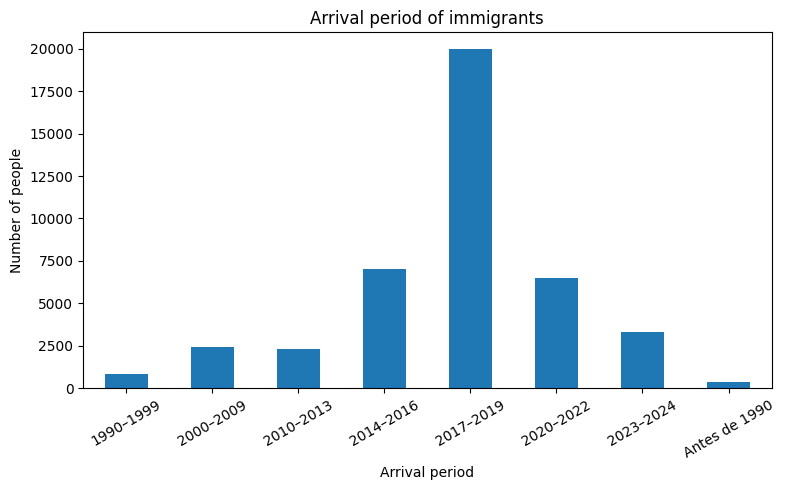

In [12]:
# 2.4 Arrival period of immigrants

# -----------------------------------
# 1. Filtrar extranjeros y valores válidos
# -----------------------------------
arr = df[
    (df["p27_nacionalidad_rec"] == 2) &
    (df["p26_llegada_periodo"] != -99)
].copy()

# -----------------------------------
# 2. Ver códigos disponibles (opcional, para verificar)
# -----------------------------------
print(sorted(arr["p26_llegada_periodo"].unique()))

# -----------------------------------
# 3. Mapear periodos (AJUSTAR si tu diccionario usa otros códigos)
# -----------------------------------
mapa_llegada = {
    8: "Antes de 1990",
    7: "1990–1999",
    6: "2000–2009",
    5: "2010–2013",
    4: "2014–2016",
    3: "2017–2019",
    2: "2020–2022",
    1: "2023–2024"
}

arr["periodo"] = arr["p26_llegada_periodo"].map(mapa_llegada)
arr = arr[arr["periodo"].notna()].copy()

# -----------------------------------
# 4. Distribución
# -----------------------------------
dist_arr = arr["periodo"].value_counts().sort_index()

# -----------------------------------
# 5. Gráfico
# -----------------------------------
import matplotlib.pyplot as plt

dist_arr.plot(kind="bar", figsize=(8,5))

plt.ylabel("Number of people")
plt.xlabel("Arrival period")
plt.title("Arrival period of immigrants")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
print(arr["p26_llegada_periodo"].value_counts().sort_index())

p26_llegada_periodo
1.0     3314
2.0     6496
3.0    19971
4.0     7004
5.0     2313
6.0     2431
7.0      832
8.0      371
Name: count, dtype: int64


La inmigración es mayoritariamente reciente, concentrándose en el periodo 2010–2019, con un peak en 2017–2019. Los periodos anteriores tienen baja participación.

In [29]:
#3.1
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Cargar el shapefile ────────────────────────────────────────────────────
# Cambia esta ruta a donde está tu shapefile
comunas_gdf = gpd.read_file(r"C:\Users\tomas\Documents\tarea1\COMUNAS")

Para crear mapas coropléticos necesitamos un shapefile con los límites geográficos de las comunas de Chile. Importamos `geopandas`, que es la librería estándar para trabajar con datos geoespaciales en Python, y `matplotlib` para graficar.

Cargamos el shapefile con `gpd.read_file()` y luego inspeccionamos sus columnas para identificar cómo se llaman el código de comuna y el nombre, ya que estos nombres varían según la fuente del shapefile.

In [24]:
print(comunas_gdf.columns.tolist())

['CUT_REG', 'CUT_PROV', 'CUT_COM', 'REGION', 'PROVINCIA', 'COMUNA', 'SUPERFICIE', 'geometry', 'codigo_comuna']


In [25]:
print(comunas_gdf[comunas_gdf["COMUNA"].str.contains("ÑUÑOA|JOAQUÍN|MAIPO", case=False, na=False)][["CUT_COM", "COMUNA"]])

    CUT_COM             COMUNA
32    13120              Ñuñoa
37    13603      Isla de Maipo
290   13203  San José de Maipo
316   13129        San Joaquín


In [26]:
print(df.columns.tolist())

['id_vivienda', 'id_hogar', 'id_persona', 'sexo', 'edad', 'p27_nacionalidad', 'p27_nacionalidad_rec', 'p24_lug_resid5', 'p25_lug_nacimiento', 'p26_llegada_periodo', 'escolaridad', 'cine11', 'sit_fuerza_trabajo', 'cod_ciuo', 'cod_caenes', 'p45_medio_transporte', 'p12_tenencia_viv', 'region', 'comuna', 'p4a_mat_paredes', 'p4b_mat_techo', 'p4c_mat_piso', 'indice_hacinamiento']


En los 3 codigos anteriores, buscamos el nombre de las columnas de nuestro Dataframe y del Shapefile, ademas, el codigo asociado a la comuna en este, por ejemplo, el codigo de Ñuñoa es "13120"

In [ ]:
#3.1
MY_COMUNAS = [13120, 13203, 13129]

# ── 1. Calcular población total por comuna desde tu df ───────────────────────
pop_by_comuna = (
    df.groupby("comuna")
    .size()
    .reset_index(name="pop_total")
)
pop_by_comuna.columns = ["codigo_comuna", "pop_total"]

# ── 2. Preparar shapefile y filtrar a tus 3 comunas ──────────────────────────
comunas_gdf["codigo_comuna"] = comunas_gdf["CUT_COM"].astype(int)

merged = comunas_gdf[comunas_gdf["codigo_comuna"].isin(MY_COMUNAS)].merge(
    pop_by_comuna, on="codigo_comuna", how="inner"
)

print(merged[["COMUNA", "codigo_comuna", "pop_total"]])

              COMUNA  codigo_comuna  pop_total
0              Ñuñoa          13120     241467
1  San José de Maipo          13203      17441
2        San Joaquín          13129      95602


En este obtuvimos la poblacion total de las tres comunas que se nos asignó

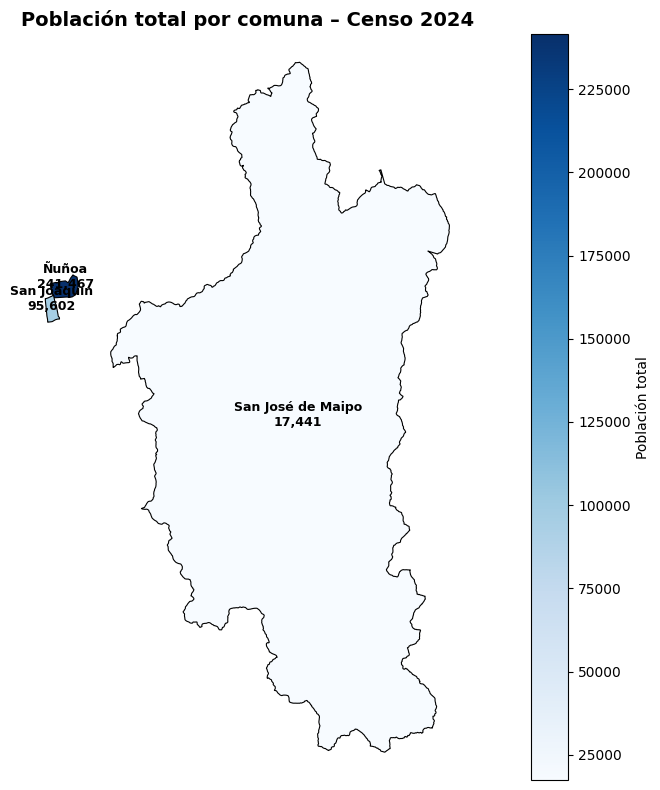

In [ ]:
#3.1
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

merged.plot(
    column="pop_total",
    ax=ax,
    cmap="Blues",
    legend=True,
    legend_kwds={"label": "Población total", "orientation": "vertical"},
    edgecolor="black",
    linewidth=0.8,
)

# Etiquetas
for _, row in merged.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=f"{row['COMUNA']}\n{row['pop_total']:,}",
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="black",
    )

# Zoom manual solo a las 3 comunas
minx, miny, maxx, maxy = merged.geometry.total_bounds  # solo merged, no comunas_gdf
padding = 0.05
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("Población total por comuna – Censo 2024", fontsize=14, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.savefig("output/mapa_poblacion.png", dpi=150, bbox_inches="tight")
plt.show()

Graficamos el mapa coroplético usando la paleta Blues

## RESUMEN Parte 3.1 – Mapa coroplético: Población total por comuna

Para visualizar espacialmente la distribución de población, utilizamos `geopandas` para cargar un shapefile oficial de comunas de Chile y lo combinamos con los datos del Censo 2024.

Primero calculamos la población total de cada comuna contando las filas en `df` agrupadas por `comuna`. Luego hacemos un *merge* entre el GeoDataFrame (shapefile) y esta tabla, usando el código CUT como llave de unión.

El mapa resultante usa una paleta de colores secuencial (`Blues`): comunas con mayor población aparecen en azul oscuro.

Ñuñoa es la comuna más poblada con 241.467 habitantes, seguida por San Joaquín con 95.602. San José de Maipo, pese a su enorme extensión geográfica, tiene solo 17.441 habitantes, lo que refleja su carácter rural y montañoso.


In [ ]:
#3.2
# ── 1. Calcular % extranjeros por comuna ─────────────────────────────────────
# p27_nacionalidad_rec: 1 = chileno, 2 = extranjero
pct_foreign = (
    df.groupby("comuna")
    .apply(lambda x: (x["p27_nacionalidad_rec"] == 2).sum() / len(x) * 100)
    .reset_index()
)
pct_foreign.columns = ["codigo_comuna", "pct_foreign"]

# ── 2. Merge con shapefile ────────────────────────────────────────────────────
merged2 = comunas_gdf[comunas_gdf["codigo_comuna"].isin(MY_COMUNAS)].merge(
    pct_foreign, on="codigo_comuna", how="inner"
)

print(merged2[["COMUNA", "codigo_comuna", "pct_foreign"]])

              COMUNA  codigo_comuna  pct_foreign
0              Ñuñoa          13120    12.115527
1  San José de Maipo          13203     3.738318
2        San Joaquín          13129    14.071881


### Parte 3.2 – Porcentaje de población extranjera por comuna

Calculamos el porcentaje de extranjeros usando `p27_nacionalidad_rec`, donde el valor `2` identifica a personas nacidas fuera de Chile. Para cada comuna dividimos el total de extranjeros por la población total y multiplicamos por 100.

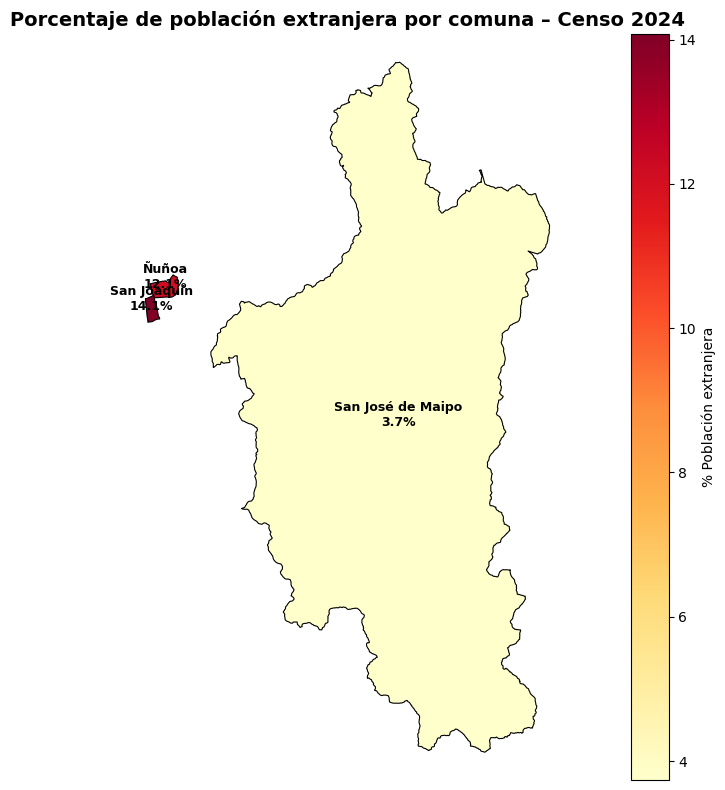

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

merged2.plot(
    column="pct_foreign",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "% Población extranjera", "orientation": "vertical"},
    edgecolor="black",
    linewidth=0.8,
)

# Etiquetas
for _, row in merged2.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=f"{row['COMUNA']}\n{row['pct_foreign']:.1f}%",
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="black",
    )

# Zoom a las 3 comunas
minx, miny, maxx, maxy = merged2.geometry.total_bounds
padding = 0.05
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("Porcentaje de población extranjera por comuna – Censo 2024", fontsize=14, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.savefig("output/mapa_pct_extranjeros.png", dpi=150, bbox_inches="tight")
plt.show()

Graficamos el segundo mapa usando la paleta `YlOrRd` (amarillo → rojo): los tonos más intensos indican mayor concentración de población extranjera. Se etiqueta cada comuna con su nombre y porcentaje exacto.

**Resumen**:  San Joaquín tiene el mayor porcentaje de extranjeros (14,07%), seguido por Ñuñoa (12,12%). Ambas son comunas urbanas densas de la Región Metropolitana, lo que es consistente con los patrones de asentamiento migrante. San José de Maipo, en cambio, registra solo un 3,74%, coherente con su perfil rural y menor acceso a servicios urbanos.

In [22]:
# ── Función build_summary ─────────────────────────────────────────────────────
def build_summary(g):
    # Filtrar missing (-99)
    g = g.copy()
    
    # Población
    pop_total = len(g)
    pop_chilean = (g["p27_nacionalidad_rec"] == 1).sum()
    pop_foreign = (g["p27_nacionalidad_rec"] == 2).sum()
    pct_foreign = pop_foreign / pop_total * 100 if pop_total > 0 else 0

    # Edad mediana
    edad_valid = g[g["edad"] != -99]
    median_age_chilean = edad_valid[edad_valid["p27_nacionalidad_rec"] == 1]["edad"].median()
    median_age_foreign  = edad_valid[edad_valid["p27_nacionalidad_rec"] == 2]["edad"].median()

    # Escolaridad (edad 25+, sin -99)
    esc = g[(g["edad"] >= 25) & (g["edad"] != -99) & (g["escolaridad"] != -99)]
    mean_schooling_chilean = esc[esc["p27_nacionalidad_rec"] == 1]["escolaridad"].mean()
    mean_schooling_foreign  = esc[esc["p27_nacionalidad_rec"] == 2]["escolaridad"].mean()

    # Tasa de empleo (edad 15-64, sit_fuerza_trabajo == 1)
    emp = g[(g["edad"] >= 15) & (g["edad"] <= 64) & (g["edad"] != -99)]
    emp_chilean = emp[emp["p27_nacionalidad_rec"] == 1]
    emp_foreign  = emp[emp["p27_nacionalidad_rec"] == 2]
    emp_rate_chilean = (emp_chilean["sit_fuerza_trabajo"] == 1).sum() / len(emp_chilean) * 100 if len(emp_chilean) > 0 else 0
    emp_rate_foreign  = (emp_foreign["sit_fuerza_trabajo"] == 1).sum() / len(emp_foreign) * 100 if len(emp_foreign) > 0 else 0

    # Dependency ratio
    edad_v = g[g["edad"] != -99]["edad"]
    dep = (((edad_v < 15) | (edad_v >= 65)).sum()) / ((edad_v.between(15, 64)).sum())

    return pd.Series({
        "pop_total":               pop_total,
        "pop_chilean":             pop_chilean,
        "pop_foreign":             pop_foreign,
        "pct_foreign":             round(pct_foreign, 2),
        "median_age_chilean":      median_age_chilean,
        "median_age_foreign":      median_age_foreign,
        "mean_schooling_chilean":  round(mean_schooling_chilean, 2),
        "mean_schooling_foreign":  round(mean_schooling_foreign, 2),
        "emp_rate_chilean":        round(emp_rate_chilean, 2),
        "emp_rate_foreign":        round(emp_rate_foreign, 2),
        "dependency_ratio":        round(dep, 4),
    })

In [23]:
# ── Aplicar y guardar ─────────────────────────────────────────────────────────
summary = df.groupby("comuna").apply(build_summary).reset_index()
summary.rename(columns={"comuna": "codigo_comuna"}, inplace=True)

# Agregar nombre de comuna
nombres = df[["comuna", "nombre_comuna"]].drop_duplicates() if "nombre_comuna" in df.columns else \
          merged[["codigo_comuna", "COMUNA"]].rename(columns={"COMUNA": "nombre_comuna"})

summary = summary.merge(nombres.rename(columns={"comuna": "codigo_comuna"}), on="codigo_comuna", how="left")

# Reordenar columnas
cols = ["codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign",
        "pct_foreign", "median_age_chilean", "median_age_foreign",
        "mean_schooling_chilean", "mean_schooling_foreign",
        "emp_rate_chilean", "emp_rate_foreign", "dependency_ratio"]
summary = summary[cols]

# Mostrar y guardar
display(summary)
summary.to_csv("output/tarea1_comuna_summary.csv", index=False)
print("✅ Guardado en output/tarea1_comuna_summary.csv")

,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13120,Ñuñoa,241467.0,210757.0,29255.0,12.12,38.0,36.0,15.67,15.94,75.98,84.84,0.3834
1,13129,San Joaquín,95602.0,81614.0,13453.0,14.07,39.0,33.0,11.85,13.20,63.16,77.73,0.4718
2,13203,San José de Maipo,17441.0,16725.0,652.0,3.74,40.0,32.0,12.29,12.82,64.25,81.12,0.4846


✅ Guardado en output/tarea1_comuna_summary.csv


## Parte 4 – Tabla Resumen a Nivel de Comuna

Definimos la función `build_summary` que, dado un grupo de filas correspondiente a una comuna, calcula todos los indicadores requeridos:

- **Población** total, chilena y extranjera, y porcentaje extranjero
- **Edad mediana** separada por origen (chileno/extranjero), excluyendo valores -99
- **Escolaridad media** para mayores de 25 años, también por origen
- **Tasa de empleo** para la población de 15 a 64 años, usando `sit_fuerza_trabajo == 1`
- **Índice de dependencia**: razón entre población dependiente (0-14 y 65+) y población activa (15-64)

En todos los cálculos se excluyen los valores `-99`, que el Censo usa para codificar datos faltantes.

Aplicamos `build_summary` a cada comuna usando `groupby` + `apply`. Luego agregamos el nombre de la comuna haciendo un merge con el shapefile, reordenamos las columnas según lo solicitado en el enunciado, mostramos la tabla y la guardamos como CSV en la carpeta `output/` para reutilizarla en la Tarea 3.

**Resumen:** Los datos muestran diferencias importantes entre comunas. Ñuñoa destaca por su alta escolaridad (15,67 años promedio en chilenos) y menor índice de dependencia (0,38), lo que refleja una población más educada y en edad activa. San Joaquín y San José de Maipo tienen índices de dependencia más altos (0,47 y 0,48), indicando una mayor proporción de población joven o adulta mayor. Llamativamente, los extranjeros tienen tasas de empleo más altas que los chilenos en las tres comunas, lo que sugiere que la migración está compuesta principalmente por personas en edad y disposición de trabajar.